DATA PREPARATION

In [110]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [111]:
# data="https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

In [112]:
# !wget $data 

In [113]:
df= pd.read_csv('car_fuel_efficiency_2026.csv')
len(df)

10000

In [114]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight',
         'model_year', 'fuel_efficiency_mpg']]

In [115]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


2.EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

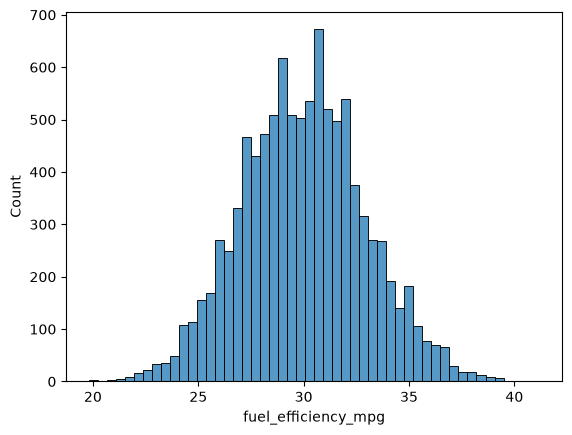

In [122]:
# No, fuel_efficiency_mpg does not have a long tail. It is close to a symmetric, bell-shaped distribution.
sns.histplot(df.fuel_efficiency_mpg,bins=50)

QUESTION 1

In [ ]:

df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

QUESTION 2

In [ ]:

df.horsepower.quantile(0.5).item()

254.0

In [ ]:

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [126]:
n_val,n_test,n_train

(2000, 2000, 6000)

In [127]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [128]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [129]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,NaN,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [130]:
idx = np.arange(n)
np.random.shuffle(idx)

In [131]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [132]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


In [133]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
5995,2280,242.0,4590,2018,29.8
5996,2300,NaN,4240,1984,25.1
5997,2240,255.0,4190,1989,27.7
5998,2430,254.0,4280,2020,31.6


QUESTION 3

1)starting a training with values filled with 0

In [134]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [135]:
base=['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
df_train[base]

,engine_displacement,horsepower,vehicle_weight,model_year
0,1900,239.0,3790,2015
1,2000,224.0,4380,1992
2,2330,286.0,4090,2022
3,2300,NaN,4150,1997
4,2340,269.0,4400,2001
...,...,...,...,...
5995,2280,242.0,4590,2018
5996,2300,NaN,4240,1984
5997,2240,255.0,4190,1989
5998,2430,254.0,4280,2020


In [136]:
X_train = df_train[base].values

In [137]:
df_train[base].isnull().sum()

engine_displacement      0
horsepower             538
vehicle_weight           0
model_year               0
dtype: int64

In [138]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

In [139]:
X_train = df_train.drop(columns='fuel_efficiency_mpg').fillna(0).values
X_val = df_val.drop(columns='fuel_efficiency_mpg').fillna(0).values

In [ ]:
# training the model
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])    

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]    

In [141]:
w0, w = train_linear_regression(X_train, y_train)

In [142]:
y_pred = w0 + X_val.dot(w)

In [151]:
def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

rmse_zero =round(rmse(y_val, y_pred),3)
rmse_zero.item()

2.205

In [146]:
# the mean option
mean_option = df_train.horsepower.mean()
mean_option

np.float64(254.46338337605272)

In [147]:
X_train_mean = df_train[base].fillna({'horsepower': mean_option}).values
X_val_mean = df_val[base].fillna({'horsepower': mean_option}).values

In [150]:
w0_m, w_m = train_linear_regression(X_train_mean, y_train)
y_pred_m = w0_m + X_val_mean.dot(w_m)

score_mean = round(rmse(y_val, y_pred_m),3)
score_mean   

np.float64(2.202)

Q3 ANS: THE MEAN OPTION IS BETTER, LOWER RMSE

In [ ]:
# QUESTION 4

In [152]:
def train_linear_regression_reg(X, y, r=0.0):
    X = np.column_stack([np.ones(X.shape[0]), X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    w_full = np.linalg.inv(XTX).dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [153]:
scores = {}

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    scores[r] = round(rmse(y_val, y_pred), 4)
    print(r, scores[r])

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [157]:
best_r, best_score = None, float('inf')

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    if scores[r] < best_score:    
        best_r, best_score = r, scores[r]

print(best_r) 

0


In [ ]:
# QUESTION 5

In [168]:
def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

In [169]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']

def score_for_seed(df, seed):
    df_train, df_val, _ = split_data(df, seed)

    X_train = df_train[base].fillna(0).values
    X_val = df_val[base].fillna(0).values
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    w0, w = train_linear_regression(X_train, y_train)  
    y_pred = w0 + X_val.dot(w)
    return rmse(y_val, y_pred)

In [178]:
scores = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    scores.append(score_for_seed(df, seed))

In [179]:
std = np.std(scores)
print(round(std, 3))    

0.029


In [ ]:
# QUESTION 6

In [ ]:
#  split with seed 9
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [173]:
df_full_train = pd.concat([df_train, df_val])

In [174]:
X_full_train = df_full_train[base].fillna(0).values
X_test = df_test[base].fillna(0).values
y_full_train = df_full_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [ ]:
# train with r=0.001
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [177]:
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)             
print(round(score, 3))

2.236
